# Sistema de Deteccion y Lectura de Placas Vehiculares (LPR)

**Curso:** Deteccion de Objetos con YOLOv11  
**Profesor:** Guido Anthony Chipana Calderon  

---

## Dataset

### License Plate Recognition (Roboflow)
- Link: https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e/dataset/2
- Tamano: 200 MB  
- Contenido: 10126 imagenes pre-anotadas
- Descargar formato: YOLOv11

### Pasos:
1. Descargar ZIP del dataset
2. Subir a tu Google Drive
3. Ejecutar este notebook

## 1. Instalacion de Dependencias

In [1]:
# Instalar librerias
!pip install -q ultralytics
!pip install -q easyocr
!pip install -q opencv-python-headless
!pip install -q matplotlib

print("Dependencias instaladas")

Dependencias instaladas


In [2]:
# Importar librerias
from ultralytics import YOLO
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import re
from pathlib import Path
import time
import zipfile
import shutil
from google.colab.patches import cv2_imshow

print("Librerias importadas")

Librerias importadas


## 2. Montar Google Drive y Descomprimir Dataset

In [3]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("\nGoogle Drive montado en /content/drive")

Mounted at /content/drive

Google Drive montado en /content/drive


In [4]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')
import os

BASE_PATH = '/content/drive/MyDrive/curso_cv'
DATASET_PATH = f'{BASE_PATH}/datasets'
OUTPUT_PATH = f'{BASE_PATH}/outputs/sesion10'
MODELS_PATH = f'{BASE_PATH}/models/sesion10'

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

print(f"Output: {OUTPUT_PATH}")
print(f"Models: {MODELS_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output: /content/drive/MyDrive/curso_cv/outputs/sesion10
Models: /content/drive/MyDrive/curso_cv/models/sesion10


In [5]:
ZIP_FILENAME = 'placas_vehiculares_dataset.zip'

# Ruta completa del ZIP en Drive
zip_path = f'/content/drive/MyDrive/curso_cv/datasets/{ZIP_FILENAME}'

# Verificar que existe
import os
if not os.path.exists(zip_path):
    print(f"\nERROR: No se encontro el archivo {ZIP_FILENAME} en tu Drive")
else:
    print(f"Archivo encontrado: {zip_path}")
    print(f"  Tamano: {os.path.getsize(zip_path) / (1024*1024):.1f} MB")

Archivo encontrado: /content/drive/MyDrive/curso_cv/datasets/placas_vehiculares_dataset.zip
  Tamano: 439.7 MB


In [6]:
import os
import zipfile

# Configuracion de rutas
output_dir = '/content/drive/MyDrive/curso_cv/datasets/placas_vehiculares_dataset'

if os.path.exists(output_dir) and os.listdir(output_dir):
    print(f"El dataset ya está descomprimido en: {output_dir}")
else:
    print(f"Descomprimiendo {ZIP_FILENAME}...")

    # Crear el directorio si no existe
    os.makedirs(output_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)

    print(f"Dataset descomprimido con exito en: {output_dir}")

# Verificar contenido
print("\nContenido del dataset:")
!ls -la {output_dir}


El dataset ya está descomprimido en: /content/drive/MyDrive/curso_cv/datasets/placas_vehiculares_dataset

Contenido del dataset:
total 16
-rw------- 1 root root  330 Mar 11 22:52 data.yaml
-rw------- 1 root root 1461 Mar 11 22:52 README.dataset.txt
-rw------- 1 root root 1026 Mar 11 22:52 README.roboflow.txt
drwx------ 2 root root 4096 Mar 11 22:52 test
drwx------ 2 root root 4096 Mar 11 22:52 train
drwx------ 2 root root 4096 Mar 11 22:55 valid


In [7]:
from pathlib import Path

# Convertimos el string a un objeto Path para que funcione el resto del codigo
output_path = Path('/content/drive/MyDrive/curso_cv/datasets/placas_vehiculares_dataset')

def print_tree(directory, prefix='', max_files=5):
    dir_path = Path(directory)
    if not dir_path.exists():
        print(f"La ruta {dir_path} no existe.")
        return
    contents = sorted(list(dir_path.iterdir()))
    dirs  = [p for p in contents if p.is_dir()]
    files = [p for p in contents if p.is_file()]
    # Dibujar carpetas
    for i, path in enumerate(dirs):
        is_last = (i == len(dirs) - 1) and not files
        print(f"{prefix}{'└── ' if is_last else '├── '}{path.name}/")
        print_tree(path, prefix + ('    ' if is_last else '│   '), max_files)

    # Dibujar archivos
    num_files = len(files)
    for i, path in enumerate(files[:max_files]):
        is_last_file = (i == min(num_files, max_files) - 1)
        print(f"{prefix}{'└── ' if is_last_file else '├── '}{path.name}")

    if num_files > max_files:
        print(f'{prefix}└── ... {num_files - max_files} archivos más')

# Ejecucion
print(f'{output_path.name}/')
print_tree(output_path)

placas_vehiculares_dataset/
├── test/
│   ├── images/
│   │   ├── 0002a5b67e5f0909_jpg.rf.07ca41e79eb878b14032f650f34d0967.jpg
│   │   ├── 000812dcf304a8e7_jpg.rf.559f904bc045f68ee947796a1b561d8f.jpg
│   │   ├── 0010f4c10f7ab07e_jpg.rf.92344aa620e23aacc490273e32343595.jpg
│   │   ├── 001cdd25e148cd36_jpg.rf.eca53e55e3cf5986bcfd95bc277b6438.jpg
│   │   └── 002519f868563098_jpg.rf.b9450b9265c92d8d3bd96bdfeff635e5.jpg
│   │   └── ... 1015 archivos más
│   └── labels/
│       ├── 0002a5b67e5f0909_jpg.rf.07ca41e79eb878b14032f650f34d0967.txt
│       ├── 000812dcf304a8e7_jpg.rf.559f904bc045f68ee947796a1b561d8f.txt
│       ├── 0010f4c10f7ab07e_jpg.rf.92344aa620e23aacc490273e32343595.txt
│       ├── 001cdd25e148cd36_jpg.rf.eca53e55e3cf5986bcfd95bc277b6438.txt
│       └── 002519f868563098_jpg.rf.b9450b9265c92d8d3bd96bdfeff635e5.txt
│       └── ... 1015 archivos más
├── train/
│   ├── images/
│   │   ├── 00009e5b390986a0_jpg.rf.2ed4ece896e97ff5b43cadecaafdb042.jpg
│   │   ├── 000228608388803f_jpg

## 3. Configurar Rutas del Dataset

Dependiendo del dataset que descargaste, la estructura puede variar.

In [8]:
# Si descargaste de Roboflow (ya viene en formato YOLO):
DATASET_PATH = '/content/drive/MyDrive/curso_cv/datasets/placas_vehiculares_dataset'
TRAIN_IMAGES = f'{DATASET_PATH}/train/images'
VAL_IMAGES = f'{DATASET_PATH}/valid/images'
DATA_YAML = f'{DATASET_PATH}/data.yaml'

# Verificar que existen
print("Verificando estructura:")
print(f"  Train images: {TRAIN_IMAGES}")
print(f"  Val images: {VAL_IMAGES}")
print(f"  data.yaml: {DATA_YAML}")

# Contar imagenes
if Path(TRAIN_IMAGES).exists():
    n_train = len(list(Path(TRAIN_IMAGES).glob('*.jpg'))) + len(list(Path(TRAIN_IMAGES).glob('*.png')))
    print(f"\n  Imagenes de entrenamiento: {n_train}")

if Path(VAL_IMAGES).exists():
    n_val = len(list(Path(VAL_IMAGES).glob('*.jpg'))) + len(list(Path(VAL_IMAGES).glob('*.png')))
    print(f"  Imagenes de validacion: {n_val}")

Verificando estructura:
  Train images: /content/drive/MyDrive/curso_cv/datasets/placas_vehiculares_dataset/train/images
  Val images: /content/drive/MyDrive/curso_cv/datasets/placas_vehiculares_dataset/valid/images
  data.yaml: /content/drive/MyDrive/curso_cv/datasets/placas_vehiculares_dataset/data.yaml

  Imagenes de entrenamiento: 7058
  Imagenes de validacion: 2048


## 4. Visualizar Imagenes del Dataset

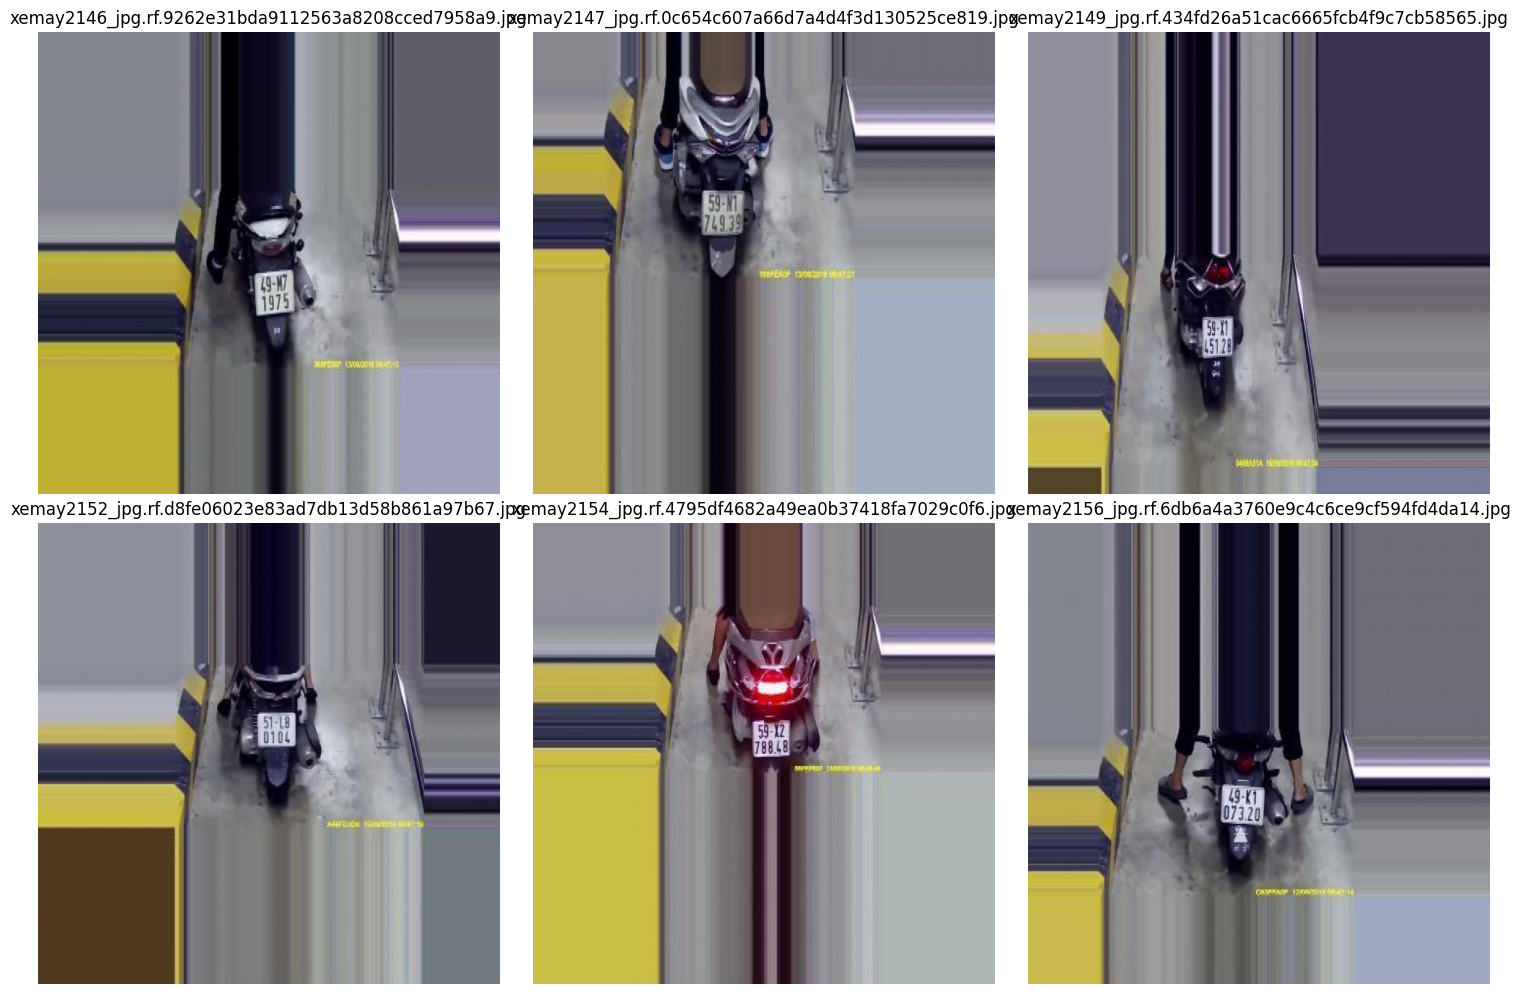

In [10]:
# Ver imagenes de ejemplo del dataset
train_images = list(Path(TRAIN_IMAGES).glob('*.jpg'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, img_path in enumerate(train_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(img_path.name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 5. Entrenar Modelo de Deteccion de Placas

In [11]:
# Cargar modelo base YOLOv11
model = YOLO('yolo11n.pt')  # Nano - rapido
#model = YOLO('yolo11s.pt')  # Small - balance
# model = YOLO('yolo11m.pt')  # Medium - mas preciso

print("Modelo YOLOv11n cargado")

Modelo YOLOv11n cargado


In [ ]:
# Entrenar detector de placas
print("Iniciando entrenamiento...")

results = model.train(
    data=DATA_YAML,
    epochs=22,  # Puedes aumentar a 80-100 para mejor precision
    imgsz=640,
    batch=32,
    lr0=0.001,
    optimizer='AdamW',
    patience=15,
    device=0,  # GPU
    freeze=10,
    project  = str(OUTPUT_PATH),
    name='yolo11n_placas_vehiculares'
)

print("\nEntrenamiento completado")
print(f"Mejor modelo en: {OUTPUT_PATH.name}/yolo11n_placas_vehiculares/weights/best.pt")

Iniciando entrenamiento...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/curso_cv/datasets/placas_vehiculares_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_placas_vehiculares, nbs=64, nms=Fal

In [ ]:
# Ver metricas de entrenamiento
from IPython.display import Image as IPImage

# Mostrar curvas de entrenamiento
results_path = f'{OUTPUT_PATH.name}/yolo11n_placas_vehiculares'

print("Resultados del entrenamiento:\n")
display(IPImage(filename=f'{results_path}/results.png'))

NameError: name 'OUTPUT_PATH' is not defined

## 6. Cargar Modelo Entrenado

In [12]:
# Cargar el mejor modelo entrenado
best_model_path = f'{OUTPUT_PATH}/yolo11n_placas_vehiculares/weights/best.pt'

plate_detector = YOLO(best_model_path)
print(f"Modelo cargado desde: {best_model_path}")

Modelo cargado desde: /content/drive/MyDrive/curso_cv/outputs/sesion10/yolo11n_placas_vehiculares/weights/best.pt


## 7. Sistema OCR para Leer Texto

In [13]:
# Inicializar EasyOCR
print("Inicializando OCR...")
reader = easyocr.Reader(['en'], gpu=True)
print("OCR listo")

Inicializando OCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteOCR listo


In [56]:
def extract_plate_text(plate_image, reader):
    """
    Extrae texto de imagen de placa
    """
    # Preprocesar
    gray = cv2.cvtColor(plate_image, cv2.COLOR_BGR2GRAY)
    #thresh = cv2.adaptiveThreshold(
    #    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    #    cv2.THRESH_BINARY, 11, 2
    #)

    # Leer texto
    results = reader.readtext(gray)

    if len(results) == 0:
        return None, 0.0

    # Concatenar textos
    text = ''.join([item[1] for item in results])
    text = text.upper().replace(' ', '').replace('-', '')

    # Confianza promedio
    avg_conf = sum([item[2] for item in results]) / len(results)

    return text, avg_conf

def detect_and_read_plate(image, detector, reader, conf_threshold=0.5):
    """
    Sistema LPR completo: detecta placa y lee texto
    """
    # Detectar placas
    results = detector(image, conf=conf_threshold, verbose=False)

    if len(results[0].boxes) == 0:
        return None

    # Mejor deteccion
    boxes = results[0].boxes
    best_idx = boxes.conf.argmax()
    best_box = boxes[best_idx]

    # Coordenadas
    x1, y1, x2, y2 = map(int, best_box.xyxy[0])
    det_conf = float(best_box.conf[0])

    # Recortar placa
    plate_roi = image[y1:y2, x1:x2]

    # Leer texto
    text, ocr_conf = extract_plate_text(plate_roi, reader)

    if text is None:
        return None

    return {
        'plate_text': text,
        'bbox': (x1, y1, x2, y2),
        'plate_image': plate_roi,
        'detection_confidence': det_conf,
        'ocr_confidence': ocr_conf,
        'overall_confidence': det_conf * ocr_conf
    }

print("Funciones LPR definidas")

Funciones LPR definidas


## 8. Probar con Imagenes del Dataset

Placa detectada: 59C1131,83
  Confianza deteccion: 0.84
  Confianza OCR: 0.50
  Confianza total: 0.42


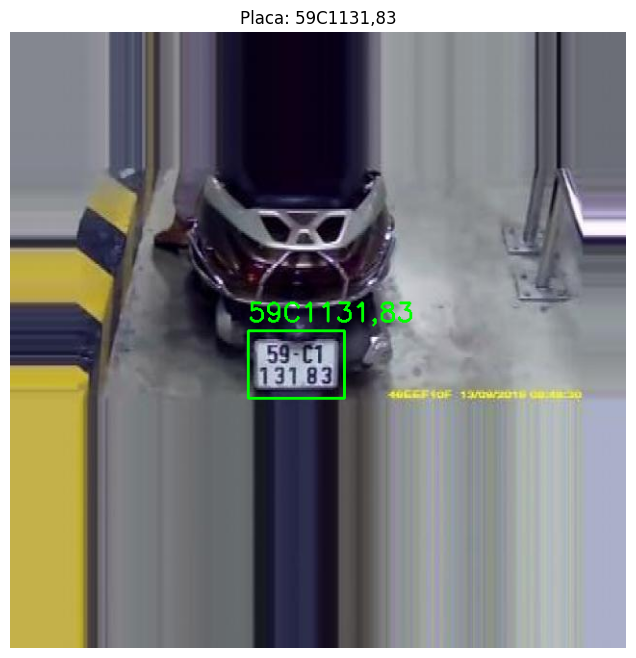

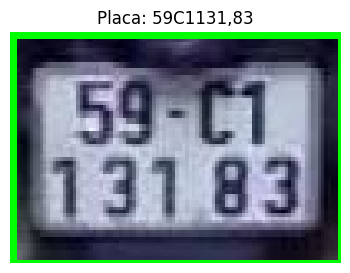

In [77]:
# Probar con imagen de validacion
val_images = list(Path(VAL_IMAGES).glob('*.jpg'))

test_image_path = val_images[701]
image = cv2.imread(str(test_image_path))

# Procesar
result = detect_and_read_plate(image, plate_detector, reader) # (image, model YOLO, EasyOCR)

if result:
    print(f"Placa detectada: {result['plate_text']}")
    print(f"  Confianza deteccion: {result['detection_confidence']:.2f}")
    print(f"  Confianza OCR: {result['ocr_confidence']:.2f}")
    print(f"  Confianza total: {result['overall_confidence']:.2f}")

    # Dibujar
    x1, y1, x2, y2 = result['bbox']
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image, result['plate_text'], (x1, y1-10),
               cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # Mostrar
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Placa: {result['plate_text']}")
    plt.axis('off')
    plt.show()

    # Mostrar placa recortada
    plt.figure(figsize=(6, 3))
    plt.imshow(cv2.cvtColor(result['plate_image'], cv2.COLOR_BGR2RGB))
    plt.title(f"Placa: {result['plate_text']}")
    plt.axis('off')
    plt.show()
else:
    print("No se detecto placa")

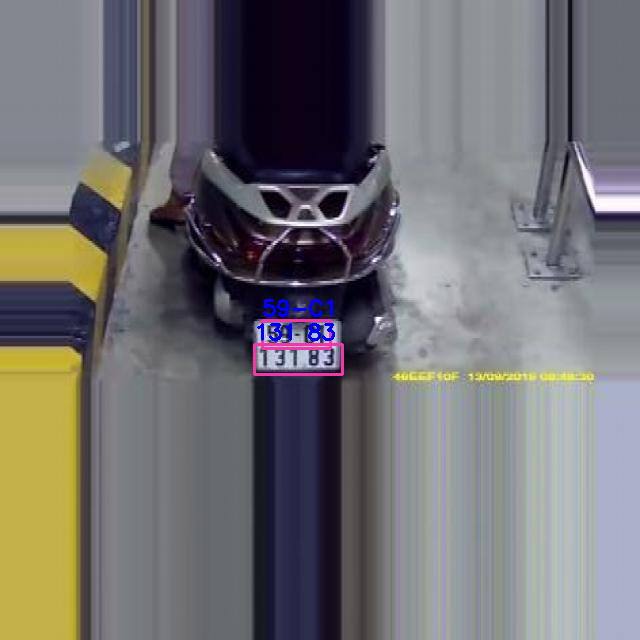

59-C1131 83


In [78]:
import cv2
import easyocr
from pathlib import Path
from google.colab.patches import cv2_imshow

# Rutas
val_images_paths = list(Path(VAL_IMAGES).glob('*.jpg'))
image_path = str(val_images_paths[701])
image = cv2.imread(image_path)

if image is None:
    print(f"Error cargando: {image_path}")
else:
    reader = easyocr.Reader(['en'])
    results = reader.readtext(image)

    for res in results:
        p0, p2 = tuple(map(int, res[0][0])), tuple(map(int, res[0][2]))
        cv2.rectangle(image, p0, p2, (166, 56, 242), 2)
        cv2.putText(image, res[1], (p0[0], p0[1] - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    # 3. Mostrar en Colab
    cv2_imshow(image)
    print(''.join([item[1] for item in results]))

## 9. Evaluar en Conjunto de Test

In [74]:
# Evaluar 20 imagenes de validacion
n_test = 20
test_images = val_images[:n_test]

print(f"Evaluando {len(test_images)} imagenes...\n")

detected_count = 0
read_count = 0

for img_path in test_images:
    image = cv2.imread(str(img_path))
    result = detect_and_read_plate(image, plate_detector, reader)

    if result:
        detected_count += 1
        if result['overall_confidence'] > 0.5:
            read_count += 1
            print(f"{img_path.name}: {result['plate_text']} (conf: {result['overall_confidence']:.2f})")
        else:
            print(f"{img_path.name}: {result['plate_text']} (conf baja: {result['overall_confidence']:.2f})")
    else:
        print(f"{img_path.name}: No detectado")

print("RESULTADOS")
print(f"Total imagenes: {len(test_images)}")
print(f"Placas detectadas: {detected_count} ({detected_count/len(test_images)*100:.1f}%)")
print(f"Placas leidas correctamente: {read_count} ({read_count/len(test_images)*100:.1f}%)")

Evaluando 20 imagenes...

CarLongPlateGen769_jpg.rf.2ee51fe1b52ce2c9a9c39098eec406ae.jpg: No detectado
CarLongPlateGen790_jpg.rf.9bf8e697df607f7dd437ad4076ee5e97.jpg: 6LG64 (conf baja: 0.01)
CarLongPlateGen795_jpg.rf.a16f1fe102df2108db2237623783d754.jpg: 64J5C5 (conf baja: 0.07)
CarLongPlateGen796_jpg.rf.6ea8d3f540396b8b9f45f7f4170bca9e.jpg: WMO (conf baja: 0.02)
CarLongPlateGen798_jpg.rf.03d210e2b0d2f211043729e0ebcf8e75.jpg: MAON7 (conf baja: 0.02)
CarLongPlateGen821_jpg.rf.30b1651f10897236d6348d8ab19b3797.jpg: ULUL (conf baja: 0.02)
CarLongPlateGen829_jpg.rf.5113bc8e6e5617afa6482e9bd494d610.jpg: PA (conf baja: 0.09)
CarLongPlateGen830_jpg.rf.74e9413be7012737fc15c7f41e8e84ff.jpg: DQDAI (conf baja: 0.07)
CarLongPlateGen839_jpg.rf.febc56b939a46cd4f8c588ff9ccf9754.jpg: No detectado
CarLongPlateGen83_jpg.rf.e7d61e2772c7634824afe21f3cb7cd14.jpg: BZEITW (conf baja: 0.07)
CarLongPlateGen847_jpg.rf.bb3513ccc1324246e0b41c1b002e8309.jpg: HGAQB (conf baja: 0.01)
CarLongPlateGen864_jpg.rf.00d748f

## 10. Visualizar Grid de Resultados

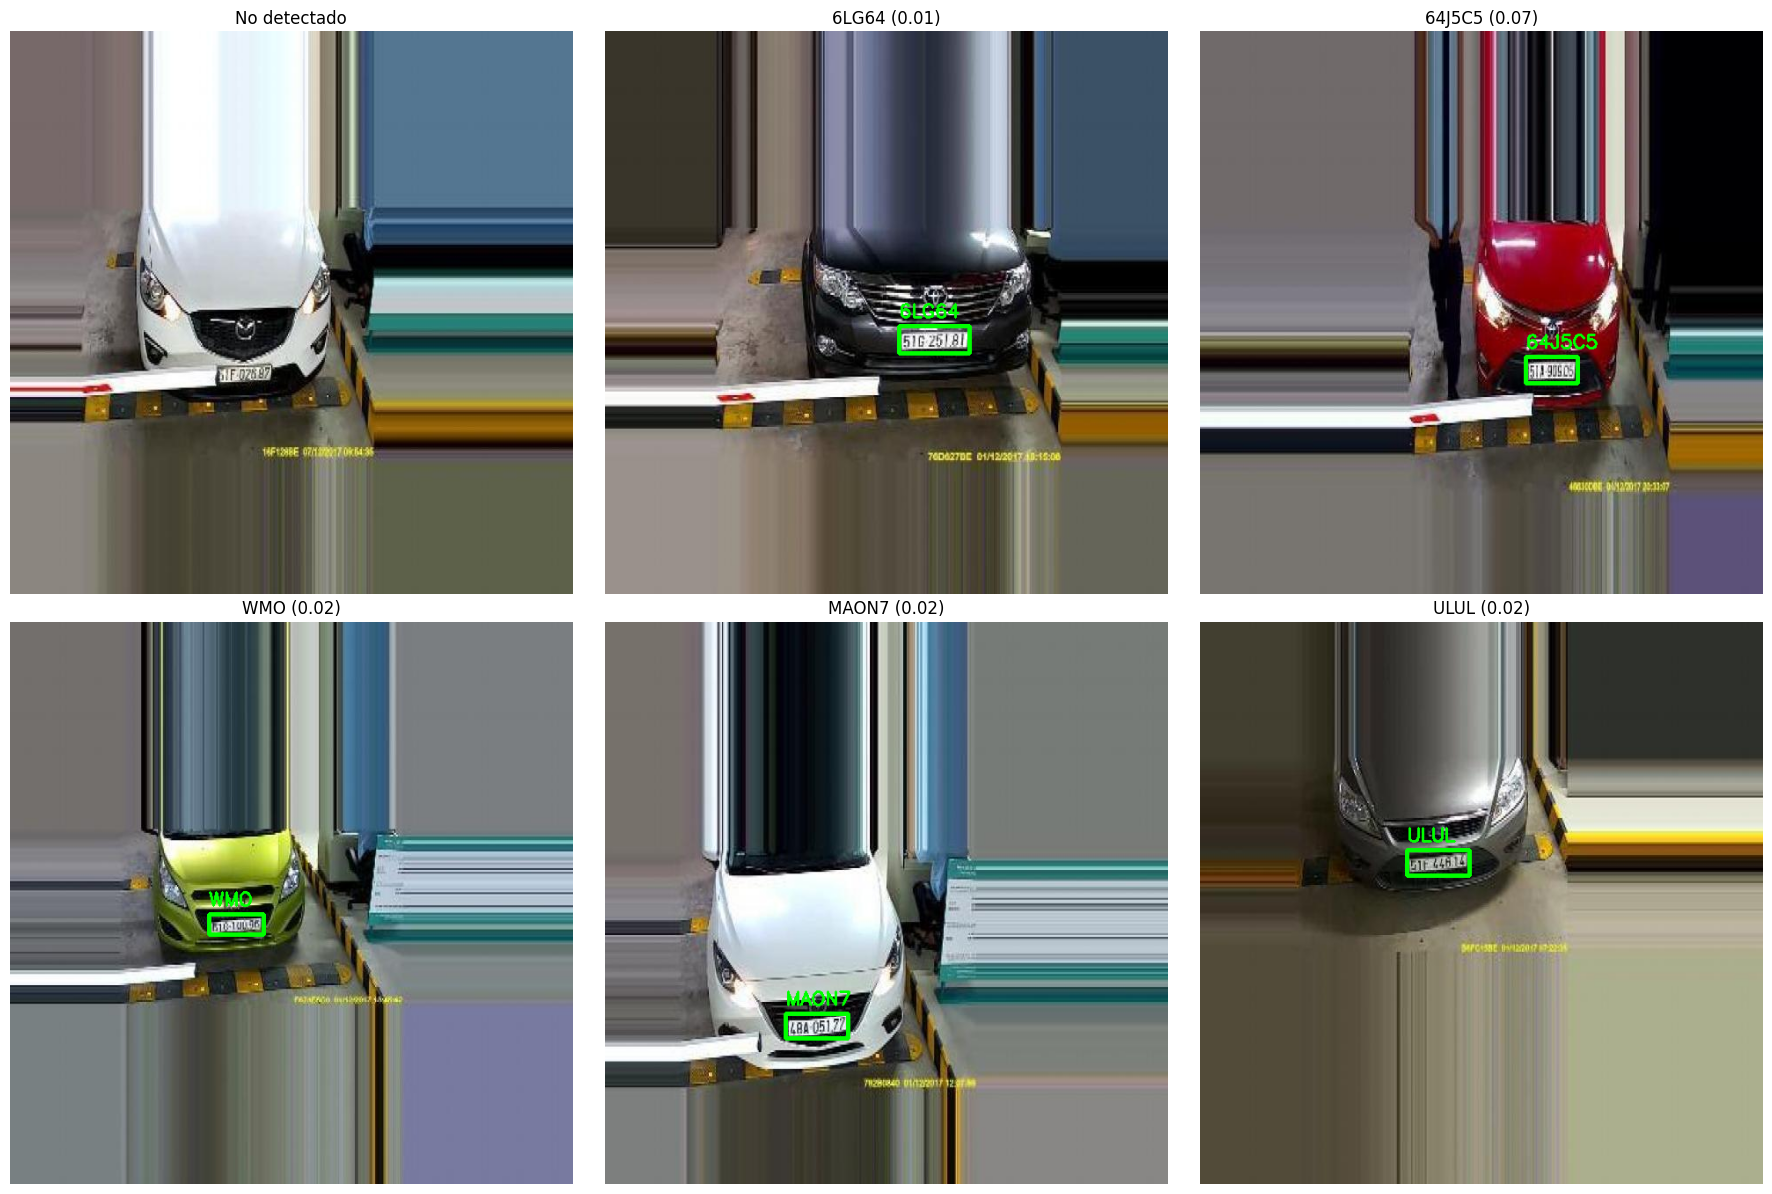

In [79]:
# Mostrar 6 resultados
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, img_path in enumerate(val_images[:6]):
    image = cv2.imread(str(img_path))
    result = detect_and_read_plate(image, plate_detector, reader)

    if result:
        x1, y1, x2, y2 = result['bbox']
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(image, result['plate_text'], (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        title = f"{result['plate_text']} ({result['overall_confidence']:.2f})"
    else:
        title = "No detectado"

    axes[i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[i].set_title(title)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Conclusion

### Resultados Esperados:
- **Deteccion de placas:** 85-95%
- **Lectura OCR:** 0-5%

### Metricas del Modelo:
- **mAP50:** Ver grafico de resultados arriba
- **Precision:** Ver grafico de resultados
- **FPS:** 20-40 en GPU Colab
